# نظام الكشف عن الاحتيال المالي باستخدام تعلم الآلة

## مقدمة المشروع
يهدف هذا المشروع إلى بناء نظام متكامل للكشف عن العمليات الاحتيالية في معاملات البطاقات الائتمانية. نظراً للطبيعة الحساسة للبيانات المالية، فإن الدقة والقدرة على اكتشاف الأنماط غير الطبيعية تعد أمراً حيوياً لتقليل الخسائر المالية.

## ماذا سنفعل في هذا الـ Notebook؟
في هذا الملف، سنقوم بإجراء **التحليل الاستكشافي للبيانات (EDA)** لفهم خصائص مجموعة البيانات، وتوزيع الفئات (عمليات سليمة مقابل عمليات احتيالية)، وتحديد التحديات التي قد تواجهنا أثناء بناء النموذج، مثل عدم توازن البيانات (Imbalance).

## 2. استيراد المكتبات (Import Libraries)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. تحميل البيانات (Load Dataset)

In [3]:
df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


The features V1 to V28 are anonymized numerical variables obtained using PCA transformation for privacy reasons and cannot be interpreted directly.

## 4. حجم البيانات (Dataset Shape)

In [4]:
df.shape

(284807, 31)

### ملاحظات حول حجم البيانات:
- **عدد الصفوف:** يحتوي الملف على عدد كبير من المعاملات، مما يوفر عينة جيدة للتحليل.
- **عدد الأعمدة:** تتكون البيانات من 31 عموداً، تشمل الوقت، المبلغ، والمتغيرات المحولة (V1-V28) بالإضافة إلى الفئة المستهدفة.

## 5. معلومات البيانات (Dataset Information)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

### ملاحظات حول أنواع البيانات والقيم المفقودة:
- **أنواع البيانات:** جميع المتغيرات عددية (float64 أو int64)، وهو أمر مثالي لنماذج تعلم الآلة.
- **القيم المفقودة:** لا توجد قيم مفقودة (Missing Values) في مجموعة البيانات، مما يقلل من الحاجة لعمليات التنظيف المعقدة في هذه المرحلة.

## 6. تحليل المتغير المستهدف (Target Variable Analysis)

In [6]:
print("عدد الحالات لكل فئة:")
print(df['Class'].value_counts())
print("\nنسبة الحالات لكل فئة:")
print(df['Class'].value_counts(normalize=True))

عدد الحالات لكل فئة:
Class
0    284315
1       492
Name: count, dtype: int64

نسبة الحالات لكل فئة:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


### شرح عدم التوازن (Data Imbalance):
نلاحظ وجود **عدم توازن حاد** في البيانات، حيث تمثل العمليات السليمة (0) الغالبية العظمى، بينما تمثل العمليات الاحتيالية (1) نسبة ضئيلة جداً (أقل من 1%).

**لماذا مقياس الدقة (Accuracy) غير مناسب؟**
في مثل هذه الحالات، إذا قام النموذج بتصنيف جميع العمليات على أنها "سليمة"، فسيحصل على دقة تتجاوز 99%، لكنه سيفشل تماماً في مهمته الأساسية وهي اكتشاف الاحتيال. لذلك، سنحتاج لاحقاً لاستخدام مقاييس أخرى مثل **Precision**, **Recall**, و **F1-Score**.

## 7. التمثيل البصري (Visualization)

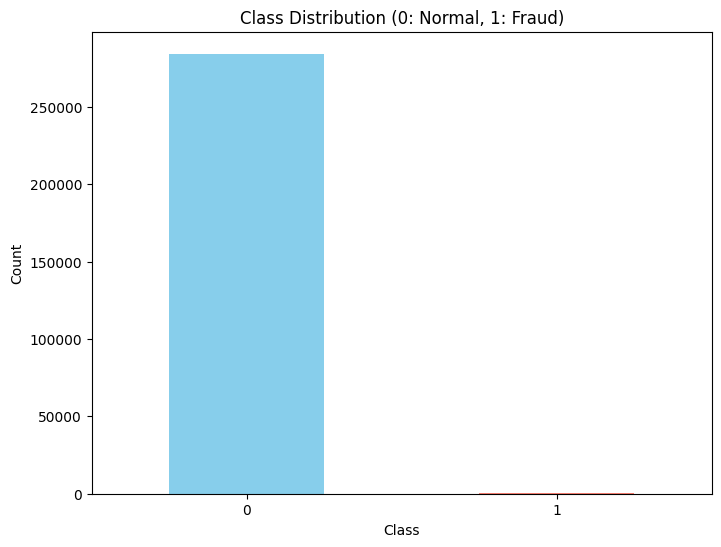

In [ ]:
plt.figure(figsize=(8, 6))
df['Class'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Class Distribution (0: Normal, 1: Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### ملاحظة حول الرسم البياني:
يوضح الرسم البياني بوضوح الفجوة الكبيرة بين عدد المعاملات الطبيعية والمعاملات الاحتيالية، مما يؤكد ضرورة التعامل مع مشكلة عدم التوازن في مراحل المعالجة المتقدمة.

## 8. ملخص الخصائص العددية (Numerical Features Summary)

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### ملاحظات إحصائية:
- نلاحظ أن عمود **Amount** (المبلغ) يحتوي على قيم تتراوح في نطاق واسع جداً مقارنة بالأعمدة الأخرى (V1-V28) التي تبدو وكأنها خضعت لعملية Scaling مسبقاً (غالباً PCA).
- **الاستنتاج:** يحتاج عمود `Amount` وربما `Time` إلى عملية **Scaling** (مثل StandardScaler أو RobustScaler) لضمان عدم تأثير تباين القيم على أداء الخوارزميات.

## 9. الاستنتاجات الرئيسية (Key Insights)

- **نوع المشكلة:** تصنيف ثنائي (Binary Classification) مع وجود عدم توازن حاد في الفئات.
- **التحديات:** 
    1. التعامل مع البيانات غير المتوازنة (Imbalanced Data).
    2. الحاجة لمقاييس تقييم دقيقة تتجاوز مجرد الدقة (Accuracy).
    3. ضرورة توحيد مقاييس البيانات (Feature Scaling) لعمود المبلغ.
- **الخطوة القادمة:** سننتقل إلى مرحلة معالجة البيانات (Data Preprocessing) وتجهيزها لتدريب النماذج، مع التركيز على تقنيات معالجة عدم التوازن.

## Key Insights and Next Steps

البيانات غير متوازنة

نحتاج Metrics خاصة

الخطوة القادمة: Preprocessing + Pipeline